**Early Heart Disease Detection (CVD Detection)**

In [1]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\yashi\OneDrive\Desktop\project3data.csv")
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,05-08-2021,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0


In [4]:
df.tail()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
69995,03-04-2018,Singapore,99993,1,19240,0,120,80,1,2,1,168,Doctor,1,76.0,0
69996,12-01-2022,Malaysia,99995,1,22601,0,140,90,2,1,2,158,Accountant,0,126.0,1
69997,25-08-2022,Malaysia,99996,0,19066,1,180,90,3,2,1,183,Accountant,0,105.0,1
69998,13-07-2020,Singapore,99998,0,22431,0,135,80,1,1,2,163,Accountant,0,72.0,1
69999,15-01-2018,Singapore,99999,1,20540,0,120,80,2,1,1,170,Teacher,0,72.0,0


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  str    
 1   country      70000 non-null  str    
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  str    
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
dtypes: float64(1), int64(12), str(3)
memory usage: 10.2 MB


,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


*Exploratory Data Analysis (EDA)*

In [6]:
df.isnull().sum()

date           0
country        0
id             0
active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
occupation     0
smoke          0
weight         0
disease        0
dtype: int64

In [7]:
print(df['occupation'].unique())

<ArrowStringArray>
[ 'Architect', 'Accountant',       'Chef',     'Lawyer',    'Teacher',
      'Nurse',   'Engineer',     'Doctor',     'Others']
Length: 9, dtype: str


In [8]:
print(df['occupation'].value_counts())

occupation
Nurse         7905
Accountant    7879
Architect     7869
Others        7813
Lawyer        7753
Chef          7723
Engineer      7707
Teacher       7683
Doctor        7668
Name: count, dtype: int64


In [9]:
print(df['country'].unique())

<ArrowStringArray>
['Indonesia', 'Malaysia', 'Singapore', 'India']
Length: 4, dtype: str


In [11]:
print(df['country'].value_counts())

country
Singapore    17671
Indonesia    17501
Malaysia     17426
India        17402
Name: count, dtype: int64


In [13]:
#changing the data type of date 
df['date'] = pd.to_datetime(df['date'],format = '%d-%m-%Y')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         70000 non-null  datetime64[us]
 1   country      70000 non-null  str           
 2   id           70000 non-null  int64         
 3   active       70000 non-null  int64         
 4   age          70000 non-null  int64         
 5   alco         70000 non-null  int64         
 6   ap_hi        70000 non-null  int64         
 7   ap_lo        70000 non-null  int64         
 8   cholesterol  70000 non-null  int64         
 9   gender       70000 non-null  int64         
 10  gluc         70000 non-null  int64         
 11  height       70000 non-null  int64         
 12  occupation   70000 non-null  str           
 13  smoke        70000 non-null  int64         
 14  weight       70000 non-null  float64       
 15  disease      70000 non-null  int64         
dtypes: datetime64[u

In [14]:
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,2021-05-03,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,2021-08-05,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,2022-11-13,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,2018-10-31,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,2020-09-25,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0


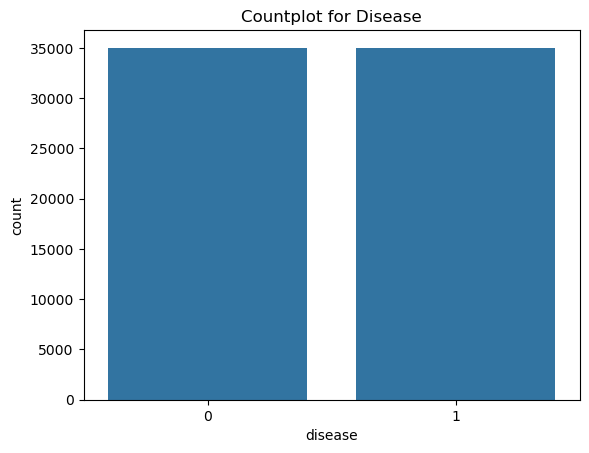

In [15]:
#Countplot
sns.countplot(x = 'disease', data=df)
plt.title("Countplot for Disease")
plt.show()

We can infer from here that the dataset is not imbalanced dataset.


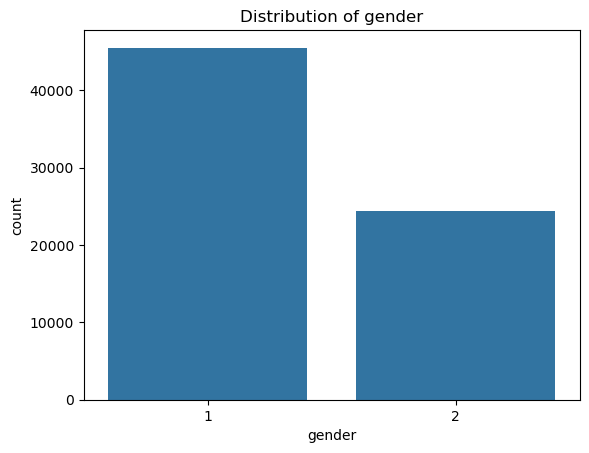

In [16]:
sns.countplot(x = 'gender',data =df)
plt.title("Distribution of gender")
plt.show()

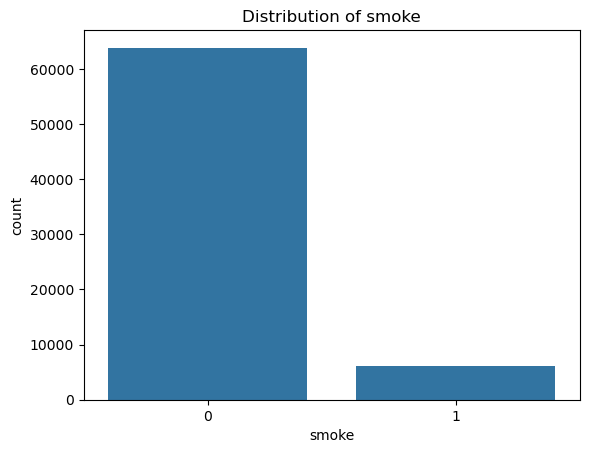

In [17]:
sns.countplot(x = 'smoke',data =df)
plt.title("Distribution of smoke")
plt.show()

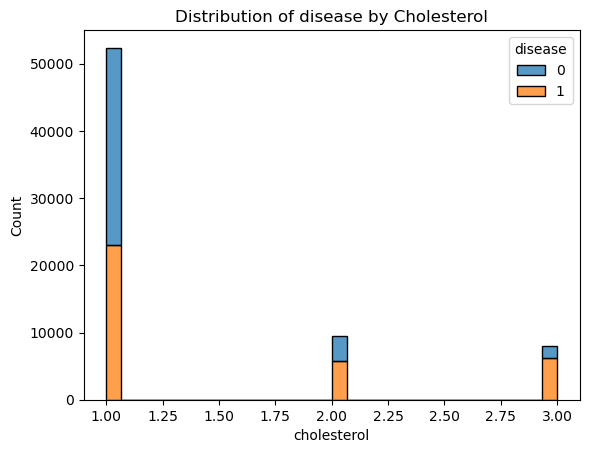

In [18]:
#Distribution of disease column on the basis of Cholesterol

sns.histplot(data=df, x= 'cholesterol', hue = 'disease',multiple='stack', bins=30)
plt.title("Distribution of disease by Cholesterol")
plt.show()

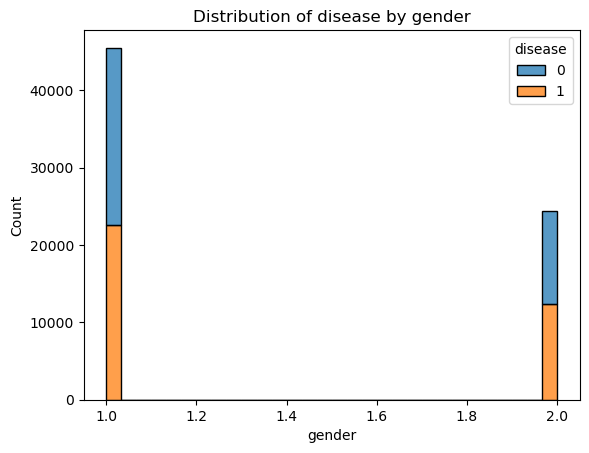

In [19]:
#Distribution of disease column on the basis of gender

sns.histplot(data=df, x= 'gender', hue = 'disease',multiple='stack', bins=30)
plt.title("Distribution of disease by gender")
plt.show()

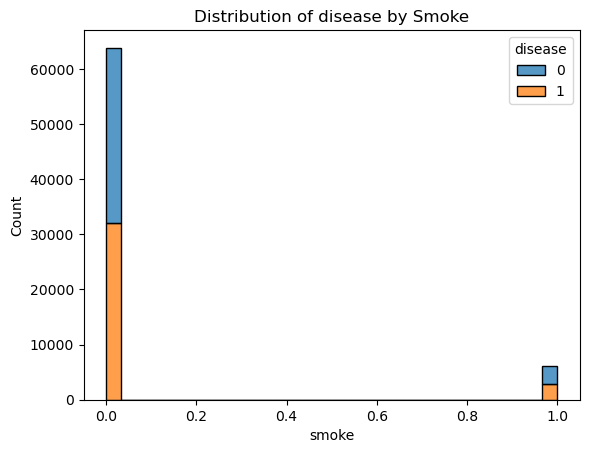

In [20]:
#Distribution of disease column on the basis of smoking column

sns.histplot(data=df, x= 'smoke', hue = 'disease',multiple='stack', bins=30)
plt.title("Distribution of disease by Smoke")
plt.show()

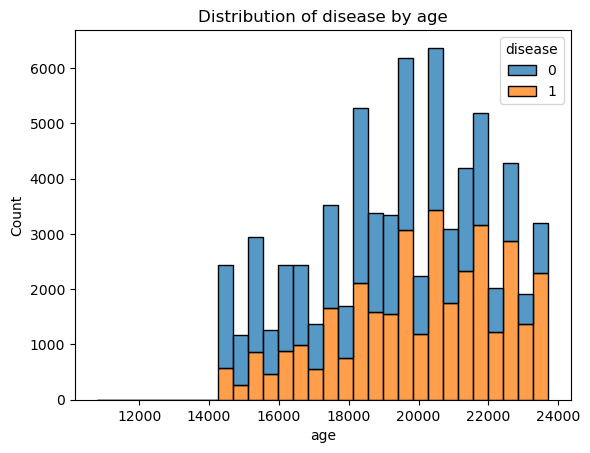

In [21]:
#Distribution of disease column on the basis of age

sns.histplot(data=df, x= 'age', hue = 'disease',multiple='stack', bins=30)
plt.title("Distribution of disease by age")
plt.show()

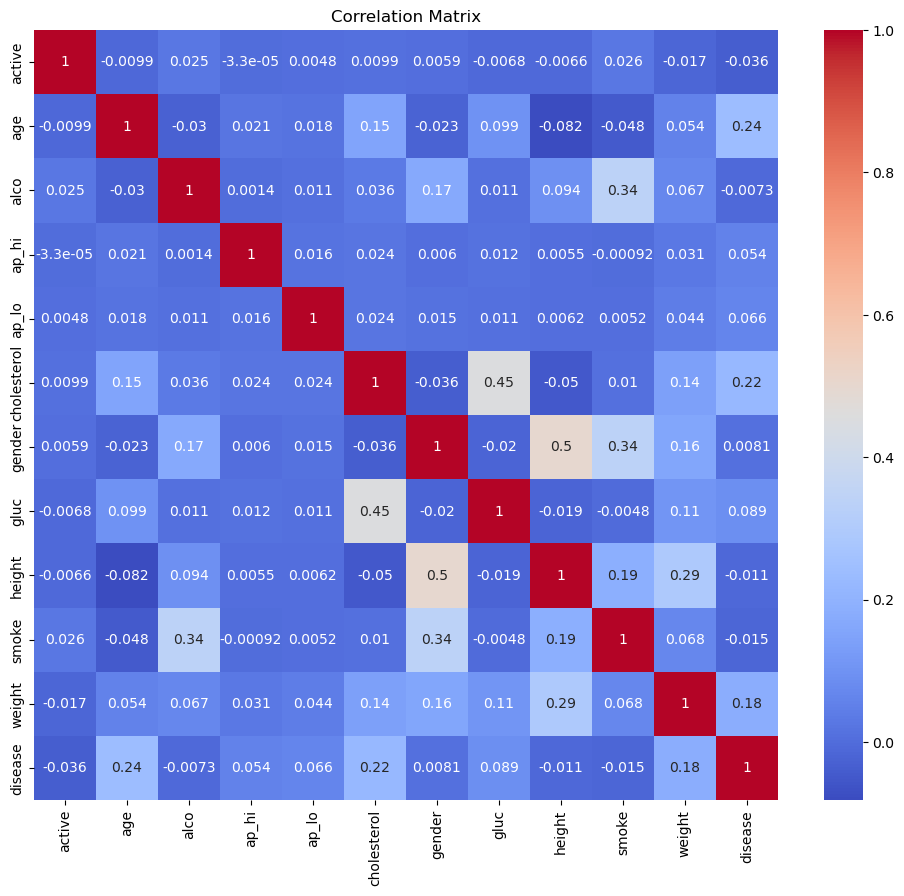

In [23]:
#Correlation matrix and heat map
w = df.drop(['date','id','country', 'occupation'],axis=1)
corr_matrix = w.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

*DATA PREPROCESSING*

In [24]:
#Categorical encoding(Label Encoding)
label_encoders={}
for column in ['country','occupation']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,2021-05-03,1,0,1,18393,0,110,80,1,2,1,168,1,0,62.0,0
1,2021-08-05,2,1,1,20228,0,140,90,3,1,1,156,0,0,85.0,1
2,2022-11-13,1,2,0,18857,0,130,70,3,1,1,165,2,0,64.0,1
3,2018-10-31,3,3,1,17623,0,150,100,1,2,1,169,5,0,82.0,1
4,2020-09-25,3,4,0,17474,0,100,60,1,1,1,156,1,0,56.0,0


In [25]:
#FEATURE ENGINEERING

df['BMI'] = df['weight'] / (df['height']/100)**2
df['cholesterol_squared'] = df['cholesterol'] ** 2
df['Hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease,BMI,cholesterol_squared,Hypertension
0,2021-05-03,1,0,1,18393,0,110,80,1,2,1,168,1,0,62.0,0,21.967120,1,0
1,2021-08-05,2,1,1,20228,0,140,90,3,1,1,156,0,0,85.0,1,34.927679,9,1
2,2022-11-13,1,2,0,18857,0,130,70,3,1,1,165,2,0,64.0,1,23.507805,9,0
3,2018-10-31,3,3,1,17623,0,150,100,1,2,1,169,5,0,82.0,1,28.710479,1,1
4,2020-09-25,3,4,0,17474,0,100,60,1,1,1,156,1,0,56.0,0,23.011177,1,0


**LOGISTIC REGRESSION MODEL** 

In [26]:
X = df.drop(['date','id','disease'],axis = 1)
y = df['disease']
X.head()

,country,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,BMI,cholesterol_squared,Hypertension
0,1,1,18393,0,110,80,1,2,1,168,1,0,62.0,21.967120,1,0
1,2,1,20228,0,140,90,3,1,1,156,0,0,85.0,34.927679,9,1
2,1,0,18857,0,130,70,3,1,1,165,2,0,64.0,23.507805,9,0
3,3,1,17623,0,150,100,1,2,1,169,5,0,82.0,28.710479,1,1
4,3,0,17474,0,100,60,1,1,1,156,1,0,56.0,23.011177,1,0


In [27]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

*Feature Scaling*

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train,y_train)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test,logreg_pred)

In [30]:
print(f'Logistic Regression Accuracy: {logreg_accuracy*100:.2f}')
print("Logistic Regression Classification Report: ")
print(classification_report(y_test,logreg_pred))

Logistic Regression Accuracy: 72.64
Logistic Regression Classification Report: 
              precision    recall  f1-score   support

           0       0.70      0.80      0.75     10539
           1       0.77      0.65      0.70     10461

    accuracy                           0.73     21000
   macro avg       0.73      0.73      0.72     21000
weighted avg       0.73      0.73      0.72     21000



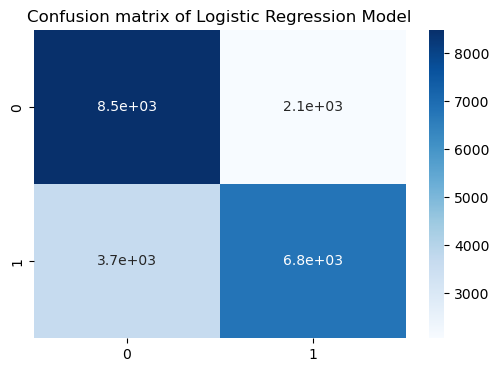

In [31]:
#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,logreg_pred), annot=True,cmap='Blues')
plt.title("Confusion matrix of Logistic Regression Model")
plt.show()

**K NEAREST NEIGHBORS MODEL (KNN)**

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

In [34]:
print(f'K Nearest Neighbors Accuracy: {knn_accuracy*100:.2f}')
print("KNN Classification Report: ")
print(classification_report(y_test,knn_pred))

K Nearest Neighbors Accuracy: 68.69
KNN Classification Report: 
              precision    recall  f1-score   support

           0       0.69      0.70      0.69     10539
           1       0.69      0.68      0.68     10461

    accuracy                           0.69     21000
   macro avg       0.69      0.69      0.69     21000
weighted avg       0.69      0.69      0.69     21000



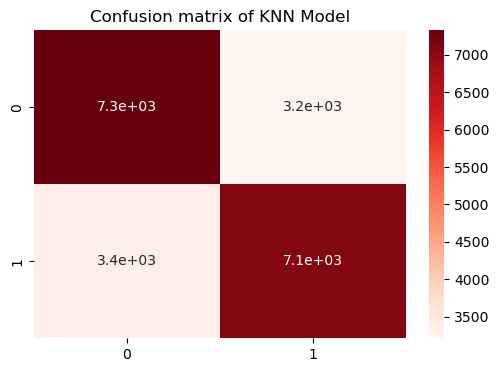

In [35]:
#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,knn_pred), annot=True,cmap='Reds')
plt.title("Confusion matrix of KNN Model")
plt.show()

**DECISION TREE MODEL**

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

In [44]:
print(f'Decision Tree Accuracy: {decision_tree_accuracy*100:.2f}')
print("Decision Tree Classification Report: ")
print(classification_report(y_test,decision_tree_pred))

Decision Tree Accuracy: 62.69
Decision Tree Classification Report: 
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     10539
           1       0.62      0.63      0.63     10461

    accuracy                           0.63     21000
   macro avg       0.63      0.63      0.63     21000
weighted avg       0.63      0.63      0.63     21000



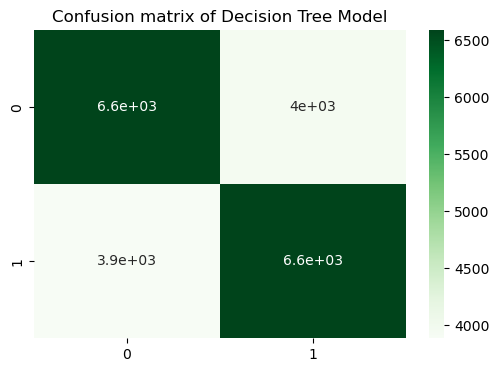

In [45]:
#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,decision_tree_pred), annot=True,cmap='Greens')
plt.title("Confusion matrix of Decision Tree Model")
plt.show()

**SVM MODEL**

In [61]:
from sklearn.svm import LinearSVC

In [62]:
svm = LinearSVC(C=1.0)
svm.fit(X_train,y_train)
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test,svm_pred)

SVM Accuracy: 72.22
SVM Classification Report: 
              precision    recall  f1-score   support

           0       0.69      0.81      0.75     10539
           1       0.77      0.63      0.69     10461

    accuracy                           0.72     21000
   macro avg       0.73      0.72      0.72     21000
weighted avg       0.73      0.72      0.72     21000



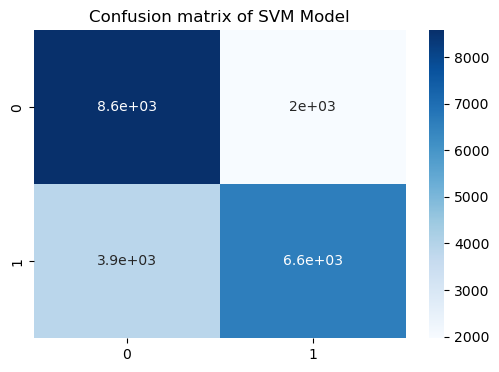

In [63]:
print(f'SVM Accuracy: {svm_accuracy*100:.2f}')
print("SVM Classification Report: ")
print(classification_report(y_test,svm_pred))

#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,svm_pred), annot=True,cmap='Blues')
plt.title("Confusion matrix of SVM Model")
plt.show()

**Now comparing all the four algorithms.**

In [64]:
print(f'Logistic Regression Accuracy: {logreg_accuracy*100:.2f}')
print(f'K Nearest Neighbors Accuracy: {knn_accuracy*100:.2f}')
print(f'Decision Tree Accuracy: {decision_tree_accuracy*100:.2f}')
print(f'SVM Accuracy: {svm_accuracy*100:.2f}')

Logistic Regression Accuracy: 72.64
K Nearest Neighbors Accuracy: 68.69
Decision Tree Accuracy: 62.69
SVM Accuracy: 72.22
